In [265]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile

### 0. Recapping Math

##### 0.1 Complex Number Space

Remember for the $x$-axis (real component) and $y$-axis (imaginary component),

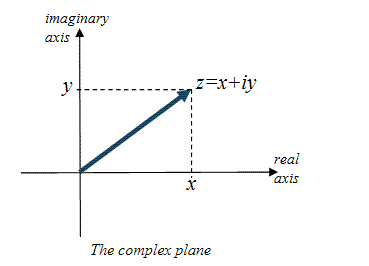

This can be represented as a $2\times2$ matrix, where $(x, y) = (a, b)$,

$z = a + bi \; \widehat{=} \begin{bmatrix}a & -b \\ b & a \end{bmatrix}$

##### 0.2 Denoting as 3-Dimensional Space in $2\times2$

Using the Pauli matrices to denote $\vec{v}=(x,y,z)$, we get,

$X = x\sigma_1 + y\sigma_2 + z\sigma_3$

In which the Pauli matrices can be denoted as,

$\sigma_1 = \begin{bmatrix}0 & 1 \\ 1 & 0 \end{bmatrix}$, $\sigma_2 = \begin{bmatrix}0 & -i \\ i & 0 \end{bmatrix}$, $\sigma_3 = \begin{bmatrix}1 & 0 \\ 0 & -1 \end{bmatrix}$

Thus can be denoted as,

$X = \begin{bmatrix}z & x -iy \\ x + iy & -z \end{bmatrix}$

##### 0.3 Picturing the Bloch Sphere

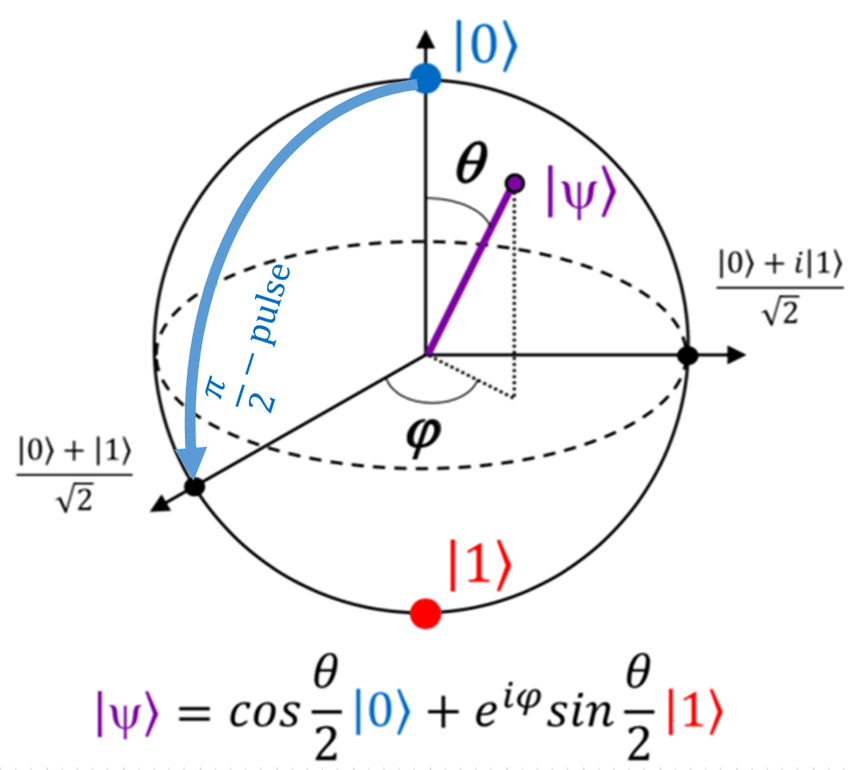

In [266]:
Aer.backends()

[AerSimulator('aer_simulator'),
 AerSimulator('aer_simulator_statevector'),
 AerSimulator('aer_simulator_density_matrix'),
 AerSimulator('aer_simulator_stabilizer'),
 AerSimulator('aer_simulator_matrix_product_state'),
 AerSimulator('aer_simulator_extended_stabilizer'),
 AerSimulator('aer_simulator_unitary'),
 AerSimulator('aer_simulator_superop'),
 QasmSimulator('qasm_simulator'),
 StatevectorSimulator('statevector_simulator'),
 UnitarySimulator('unitary_simulator')]

### 1. Phase
#### 1.1 Starting with the $Z$ Phase Gate

> Shifts the phase (a complex number component) of the Qubit's state (e.g. from $a + bi$ to $a - bi$).

Refer to: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.ZGate

Matrix representation:

$
Z = \begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$

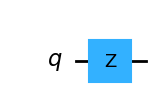

In [267]:
qc = QuantumCircuit(1)
qc.z(0)
qc.draw('mpl')

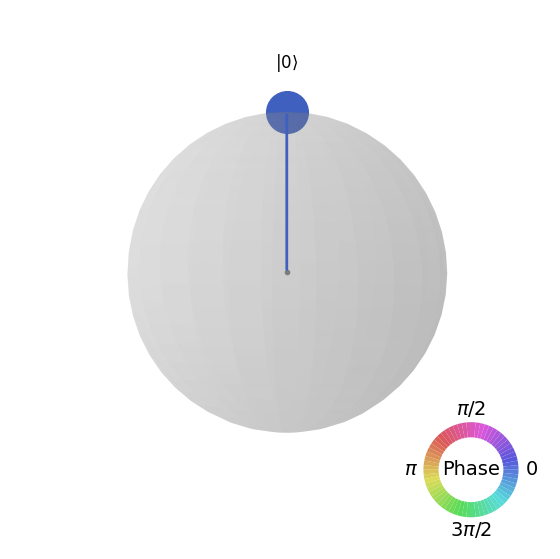

In [268]:
state = Statevector.from_instruction(qc)
plot_state_qsphere(state)

#### 1.2 Adding the $H$ (Hadamard) Gate

> Fundamental quantum operation used to put a qubit into an equal superposition of $|0⟩$ and $|1⟩$ (both states at once), enabling quantum parallelism and interference

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.HGate

$
H = \frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
$

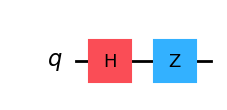

In [269]:
qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)
qc.draw('mpl')

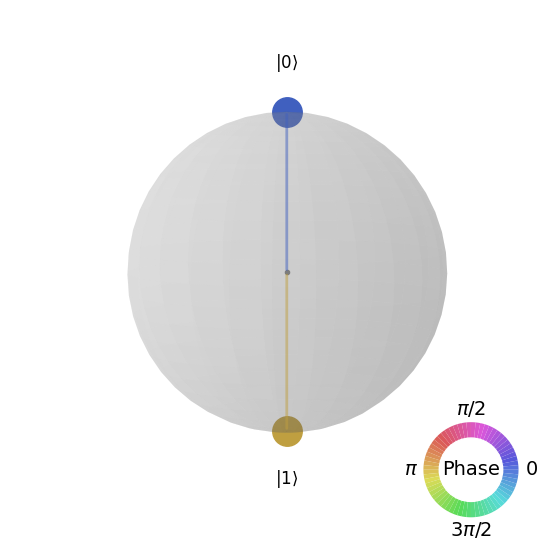

In [253]:
state = Statevector.from_instruction(qc)
plot_state_qsphere(state)

### 2. Phase and Bloch Sphere
#### 2.1 Running on Simulators

In [241]:
import math
from qiskit.quantum_info import DensityMatrix, Statevector

In [242]:
qasm_simulator = Aer.get_backend('qasm_simulator')
statevector_simulator = Aer.get_backend('statevector_simulator')

In [311]:
def run_on_simulators(circuit):
    compiled_circuit = transpile(circuit, backend=statevector_simulator)
    job = statevector_simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    statevec = result.get_statevector()
    num_qubits = circuit.num_qubits
    # r = [i for i in range(num_qubits)]
    # circuit.measure(r, r)
    circuit.measure_all()
    return result, statevec or Statevector([])

#### 2.2 Running with $RX$ Rotate-$x$ Gate

> Rotates a qubit's state around the $x$-axis of the Qubit's Bloch sphere by a specified angle ($θ$), acting as a fundamental tool for state preparation, creating superpositions, and manipulating quantum information in quantum algorithms.

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RXGate

Matrix:

$
RX(θ) = \begin{bmatrix}
cos(θ/2) & -i sin(θ/2) \\
-i sin(θ/2) & cos(θ/2)
\end{bmatrix}
$

---

For the $RY$ Rotate-$y$ Gate on the $y$-axis,

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RYGate

Matrix:

$
RY(θ) = \begin{bmatrix}
cos(θ/2) & -sin(θ/2) \\
sin(θ/2) & cos(θ/2)
\end{bmatrix}
$

---

For the $RZ$ Rotate-$z$ Gate on the $z$-axis,

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RZGate

Matrix:

$
RZ(φ) = \begin{bmatrix}
e^{-i\frac{φ}{2}} & 0 \\
0 & e^{i\frac{φ}{2}}
\end{bmatrix}
$





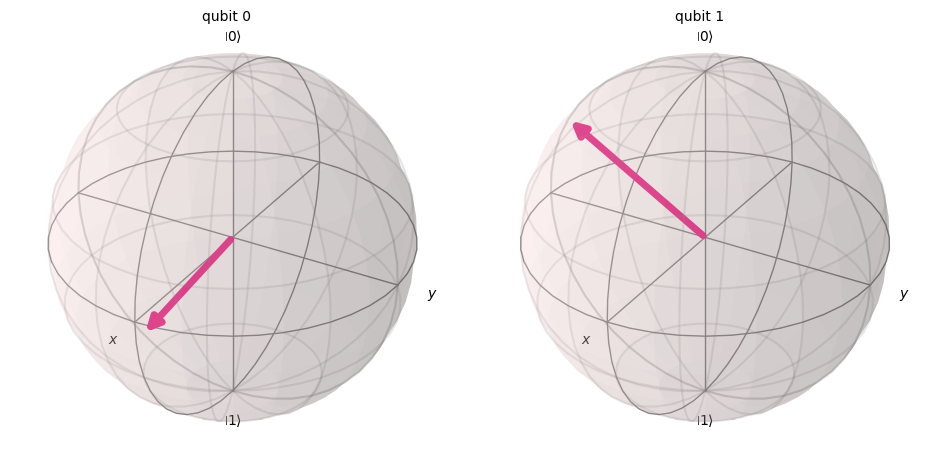

In [312]:
qc = QuantumCircuit(2,2)
qc.rx(-1.2*math.pi, 0)
qc.rx(math.pi/3, 1)
result, statevec = run_on_simulators(qc)
plot_bloch_multivector(statevec)

#### 2.3 Understanding Phase Gate

1. Use Hadamard Gate itself first
2. Apply Phase Gate to see switch in direction

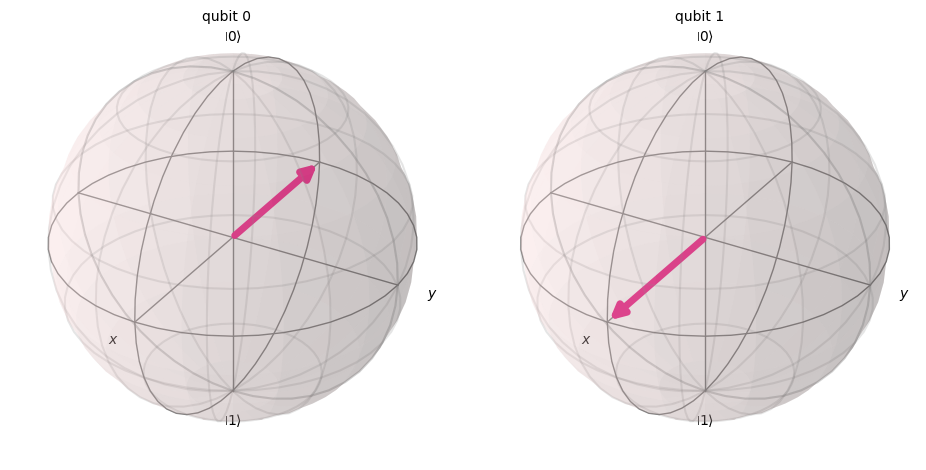

In [313]:
qc = QuantumCircuit(2,2)
qc.h(0)
qc.z(0)
qc.h(1)
result, statevec = run_on_simulators(qc)
plot_bloch_multivector(statevec)

#### 2.5 Using the CNOT (Controlled NOT) Gate

> Fundamental two-qubit quantum logic gate that flips the state of a "target" qubit only if a "control" Qubit is in the $|1⟩$ state. This is also known as the Controlled Pauli-X Gate

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CXGate

Matrix:

$
CX q_0, q_1 = I ⊗ ∣0⟩⟨0∣ + X ⊗ ∣1⟩⟨1∣ = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
$

Recall that $⊗$ is a tensor product,

$$
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\otimes
\begin{bmatrix}
e & f \\
g & h
\end{bmatrix}
=
\begin{bmatrix}
ae & af & be & bf \\
ag & ah & bg & bh \\
ce & cf & de & df \\
cg & ch & dg & dh
\end{bmatrix}
$$

In [314]:
qc = QuantumCircuit(2,2)
qc.h(0)
#qc.rx(math.pi * 4/5, 0)
result, statevec = run_on_simulators(qc)
print(result.get_counts())

{'00': 1024}


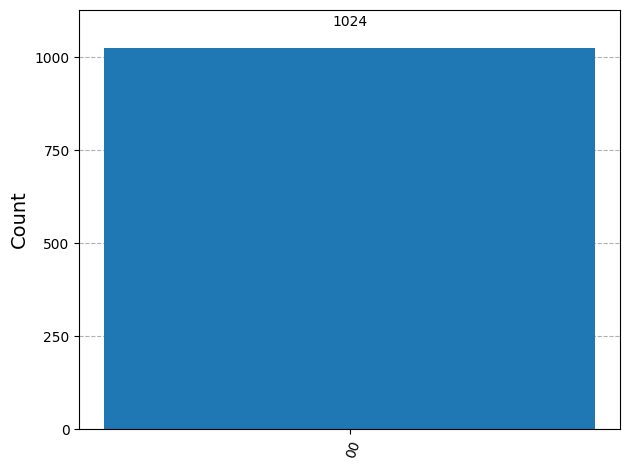

In [315]:
plot_histogram(result.get_counts())

In [316]:
qc.cx(0, 1)
result, statevec = run_on_simulators(qc)
print(result.get_counts())

{'00 00': 513, '01 00': 511}


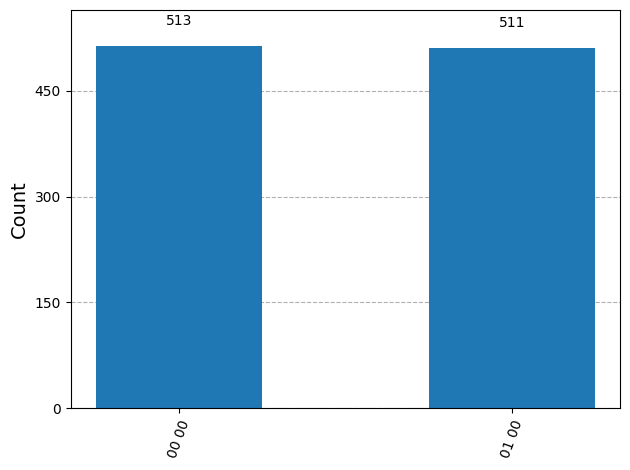

In [317]:
plot_histogram(result.get_counts())

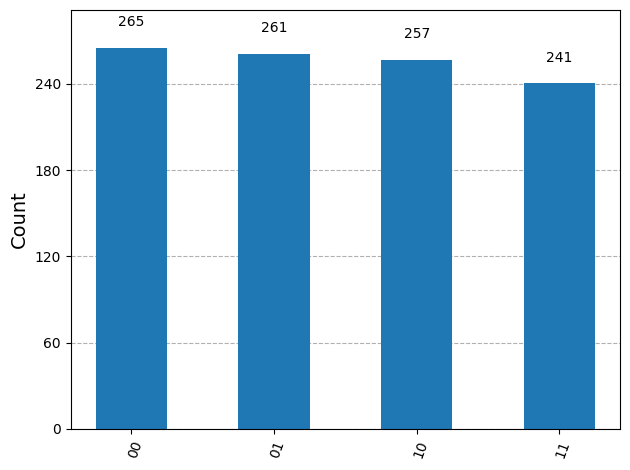

In [318]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)
qc.measure([0, 1], [0, 1])
result, statevec = run_on_simulators(qc)
plot_histogram(result.get_counts())

### 3. Superdense Coding

Alice and Bob starts with a shared Bell pair and choose 2 bits (`11` and `01`), and for Bob to recover Alice's selected bits, he has to apply a CNOT + H operation (e.g. opposite of result and switching the result into compoutational basis from superposition state).

_Note that H Gate (computational -> H → superposition -> H → computational -> H → superposition, ..)._

1. Identity Gate: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.IGate
2. Pauli X Gate: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.XGate
3. Pauli Z Gate: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.ZGate

Below are the operations for apply
| Alice Bit | Bob Bit (Entangled) | Immutable Gate | Name of Gate | Rotation | Operation | Message |
| -- | -- | -- | -- | -- | -- | -- | 
| `1`1 | `0`1 | $I = \begin{bmatrix}1&0\\0&1\end{bmatrix}$ | Identity Gate | - | $\|Φ+⟩ → \frac{1}{\sqrt{2}}(\|00⟩ + \|11⟩)$ or $\frac{1}{\sqrt{2}}(\|00⟩ + \|01⟩)$ | $00$ |
| `0`1 | `1`1 | $X = \begin{bmatrix}0&1\\1&0\end{bmatrix}$  | Pauli X Gate | $$R_x(π)$$ | $\|Ψ+⟩ → \frac{1}{\sqrt{2}}(\|10⟩ + \|01⟩)$ or $\frac{1}{\sqrt{2}}(\|10⟩ + \|11⟩)$ | $10$ |
| `1`1 | `0`1 | $Z = \begin{bmatrix}1&0\\0&-1\end{bmatrix}$ | Pauli Z Gate | $$R_z(π)$$ | $\|Φ-⟩ → \frac{1}{\sqrt{2}}(\|00⟩ - \|11⟩)$ or $\frac{1}{\sqrt{2}}(\|00⟩ - \|01⟩)$ | $01$ |
| `0`1 | `1`1 | $X \cdot Z = \begin{bmatrix}0&-1\\1&0\end{bmatrix}$ | Pauli X then Z Gate | $e^{-i\frac{\pi}{2}} R_y(\pi)$ | $\|Ψ-⟩ → \frac{1}{\sqrt{2}}(\|10⟩ - \|01⟩)$ or $\frac{1}{\sqrt{2}}(\|10⟩ - \|11⟩)$ | $11$ |

---

For this operations, it does not include the Pauli Y Gate, which rotates as $R_y(π)$, although for reference in terms of relations,

$Y = \begin{bmatrix}0&-i\\i&0\end{bmatrix}$ 

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.YGate

In [ ]:
class SuperDense:

    def __init__(self):
        # Sharing of the Bell pair (H + CNOT)
        self.qc = QuantumCircuit(2, 2)
        self.qc.h(0)
        self.qc.cx(0, 1)
    
    def encode(self, message_bits):
        # Identity means nothing
        if message_bits == "00":
            pass
        # Pauli X Gate application
        elif message_bits == "10":
            self.qc.x(0)
        # Pauli Z Gate application
        elif message_bits == "01":
            self.qc.z(0)
        # Pauli X then Z Gate application
        elif message_bits == "11":
            self.qc.x(0)
            self.qc.z(0)

    def decode(self):
        self.qc.cx(0, 1)
        self.qc.h(0)
    
    def measure(self):
        # Each call collapses the state and mutates the circuit, so create a copy to not mutate the original circuit
        measured = self.qc.copy()
        measured.measure([0,1], [0,1])
        result, _ = run_on_simulators(measured)
        counts = result.get_counts()
        decoded = max(counts, key=counts.get)
        return decoded

Alice sends `00` message to Bob:

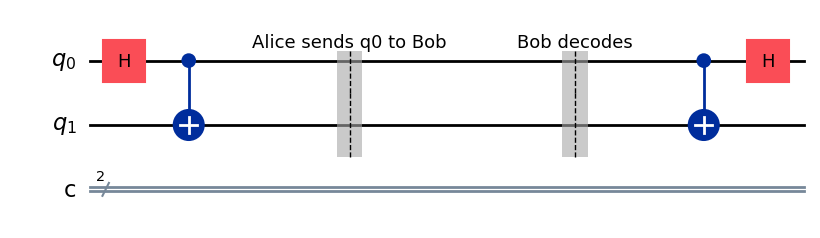

In [361]:
sd = SuperDense()
sd.qc.barrier(label="Alice sends q0 to Bob")
sd.encode('00')
sd.qc.barrier(label="Bob decodes")
sd.decode()
sd.qc.draw("mpl")

In [362]:
print('Decoded:', sd.measure())

Decoded: 00


Alice sends `10` message to Bob:

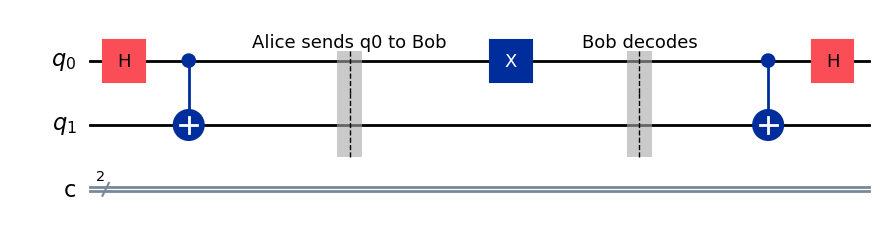

In [363]:
sd = SuperDense()
sd.qc.barrier(label="Alice sends q0 to Bob")
sd.encode('10')
sd.qc.barrier(label="Bob decodes")
sd.decode()
sd.qc.draw("mpl")

In [364]:
print('Decoded:', sd.measure())

Decoded: 10


Alice sends `01` message to Bob:

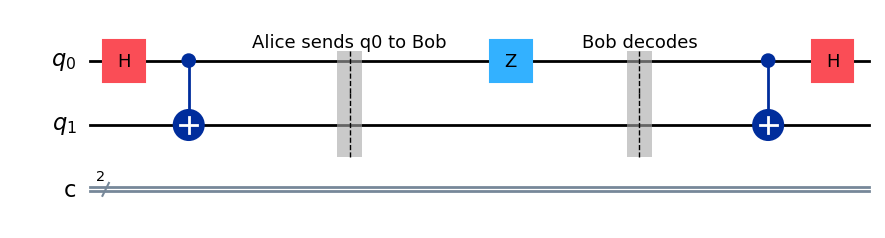

In [365]:
sd = SuperDense()
sd.qc.barrier(label="Alice sends q0 to Bob")
sd.encode('01')
sd.qc.barrier(label="Bob decodes")
sd.decode()
sd.qc.draw("mpl")

In [366]:
print('Decoded:', sd.measure())

Decoded: 01


Alice sends `11` message to Bob:

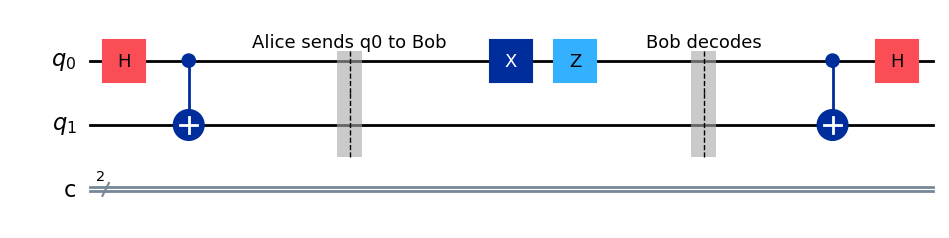

In [367]:
sd = SuperDense()
sd.qc.barrier(label="Alice sends q0 to Bob")
sd.encode('11')
sd.qc.barrier(label="Bob decodes")
sd.decode()
sd.qc.draw("mpl")

In [368]:
print('Decoded:', sd.measure())

Decoded: 11
